In [1]:
pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.5 MB/s eta 0:00:00


In [2]:
from google_play_scraper import reviews, Sort
import csv
import pandas as pd
from transformers import pipeline

result, _ = reviews(
    'id.go.jakarta.smartcity.jaki',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=3000,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

# Load the CSV into a pandas DataFrame
df = pd.read_csv(filename)

# Initialize the sentiment analysis pipeline using a pre-trained IndoRoberta model
# A common model for Indonesian sentiment analysis is 'w11wo/indonesian-roberta-base-sentiment-classifier'
sentiment_pipeline = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-sentiment-classifier")

# Perform sentiment analysis on the 'content' column
# This might take some time depending on the number of reviews
sentiment_results = sentiment_pipeline(df['content'].tolist())

# Extract sentiment label and score
df['sentiment_label'] = [res['label'] for res in sentiment_results]
df['sentiment_score'] = [res['score'] for res in sentiment_results]

# Display reviews with their sentiment analysis results
print("\nUlasan dengan Analisis Sentimen:")
print(df[['content', 'sentiment_label', 'sentiment_score']].head())

Berhasil menyimpan 3000 ulasan ke 'ulasan_google_play.csv'


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


Ulasan dengan Analisis Sentimen:
                                             content sentiment_label  \
0                        keren ,,good job jakarta ♥️        positive   
1                                    Tidak fleksibel        negative   
2                                             mantul         neutral   
3                                             dicoba         neutral   
4  saya mau tanya ke jaki sebenarnya saya harus l...        negative   

   sentiment_score  
0         0.996456  
1         0.991225  
2         0.898365  
3         0.612354  
4         0.985014  


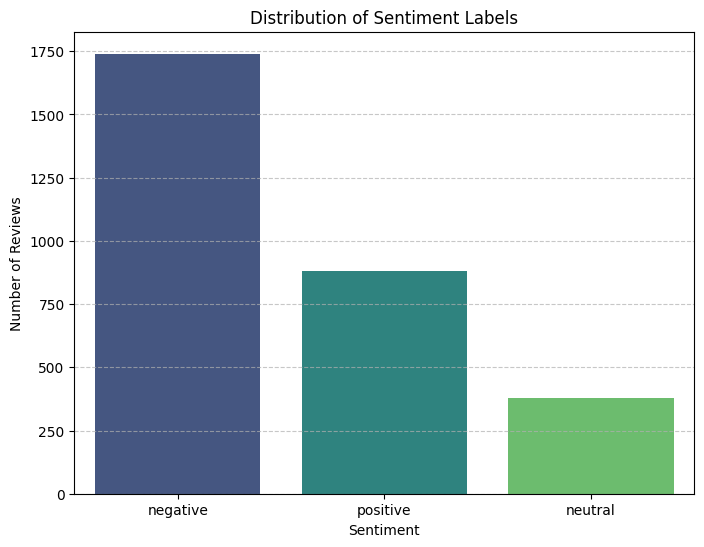

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each sentiment label
sentiment_counts = df['sentiment_label'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Sentiment', y='Count', data=sentiment_counts, hue='Sentiment', palette='viridis', legend=False)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [4]:
# Save the DataFrame with sentiment analysis results to a new CSV file
df.to_csv('hasil_analisis_sentimen_JakartaKini.csv', index=False)
print("DataFrame saved to 'hasil_analisis_sentimen_JakartaKini.csv'")

# Display the first 5 rows of the DataFrame to confirm
print("\nFirst 3000 rows of the DataFrame with sentiment analysis:")
display(df.head())

DataFrame saved to 'hasil_analisis_sentimen_JakartaKini.csv'

First 3000 rows of the DataFrame with sentiment analysis:


,userName,score,at,content,sentiment_label,sentiment_score
0,Pengguna Google,5,2026-04-29 07:22:52,"keren ,,good job jakarta ♥️",positive,0.996456
1,Pengguna Google,1,2026-04-29 03:28:11,Tidak fleksibel,negative,0.991225
2,Pengguna Google,5,2026-04-28 03:32:32,mantul,neutral,0.898365
3,Pengguna Google,2,2026-04-28 00:53:11,dicoba,neutral,0.612354
4,Pengguna Google,1,2026-04-24 05:14:01,saya mau tanya ke jaki sebenarnya saya harus l...,negative,0.985014
